In [87]:
import optuna
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [88]:
study = optuna.load_study(
    storage=r"sqlite:///../../results/exploratory/1000_optuna/optuna.sqlite3",
    study_name="resnet50_64img_1pilse_1sample_0.5delay",
)

In [89]:
df = study.trials_dataframe()

In [90]:
df_failed = df[df.value == 0.825]
df_unchanged = df[df.value == 0.6875]
df_one = df[df.value == 0.671875]
df_success = df[df.value < 0.4]

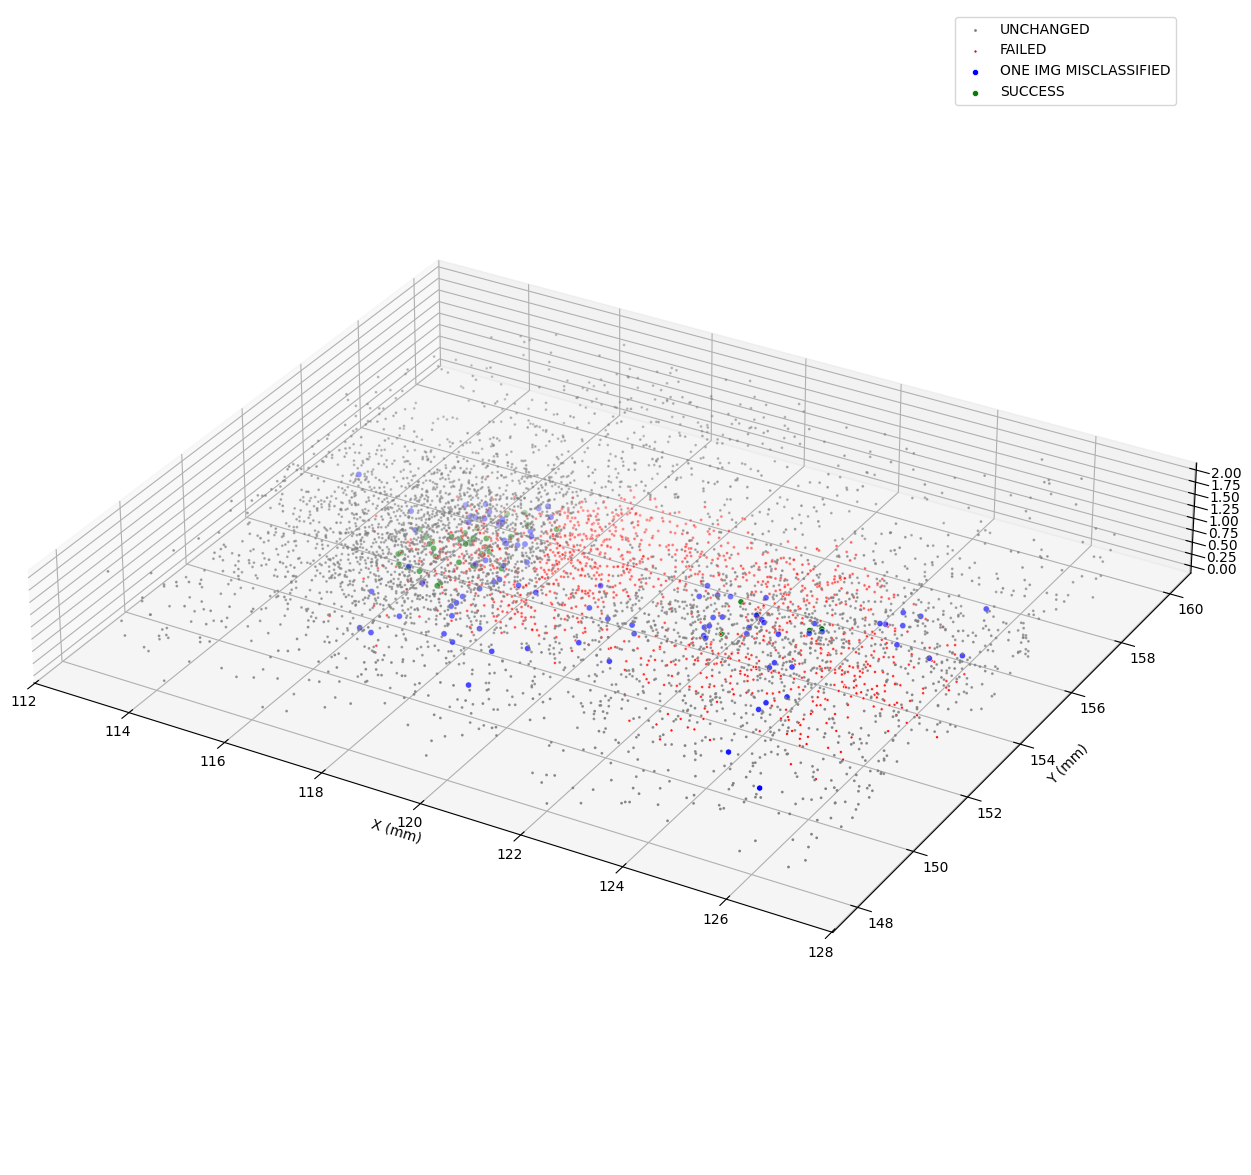

In [91]:
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection="3d")

x_range = df["params_x"].max() - df["params_x"].min()
y_range = df["params_y"].max() - df["params_y"].min()
z_range = df["params_z"].max() - df["params_z"].min()

ax.set_box_aspect((x_range, y_range, z_range))

ax.scatter(
    df_unchanged["params_x"],
    df_unchanged["params_y"],
    df_unchanged["params_z"],
    c="gray",
    s=1,
    label="UNCHANGED",
)

ax.scatter(
    df_failed["params_x"],
    df_failed["params_y"],
    df_failed["params_z"],
    c="red",
    s=5,
    edgecolor="w",
    linewidth=0.5,
    label="FAILED",
)

ax.scatter(
    df_one["params_x"],
    df_one["params_y"],
    df_one["params_z"],
    c="blue",
    s=20,
    edgecolor="w",
    linewidth=0.5,
    label="ONE IMG MISCLASSIFIED",
)

ax.scatter(
    df_success["params_x"],
    df_success["params_y"],
    df_success["params_z"],
    c="green",
    s=20,
    edgecolor="w",
    linewidth=0.5,
    label="SUCCESS",
)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")
ax.legend()

plt.savefig("../../results/exploratory/1000_optuna/3d.svg")

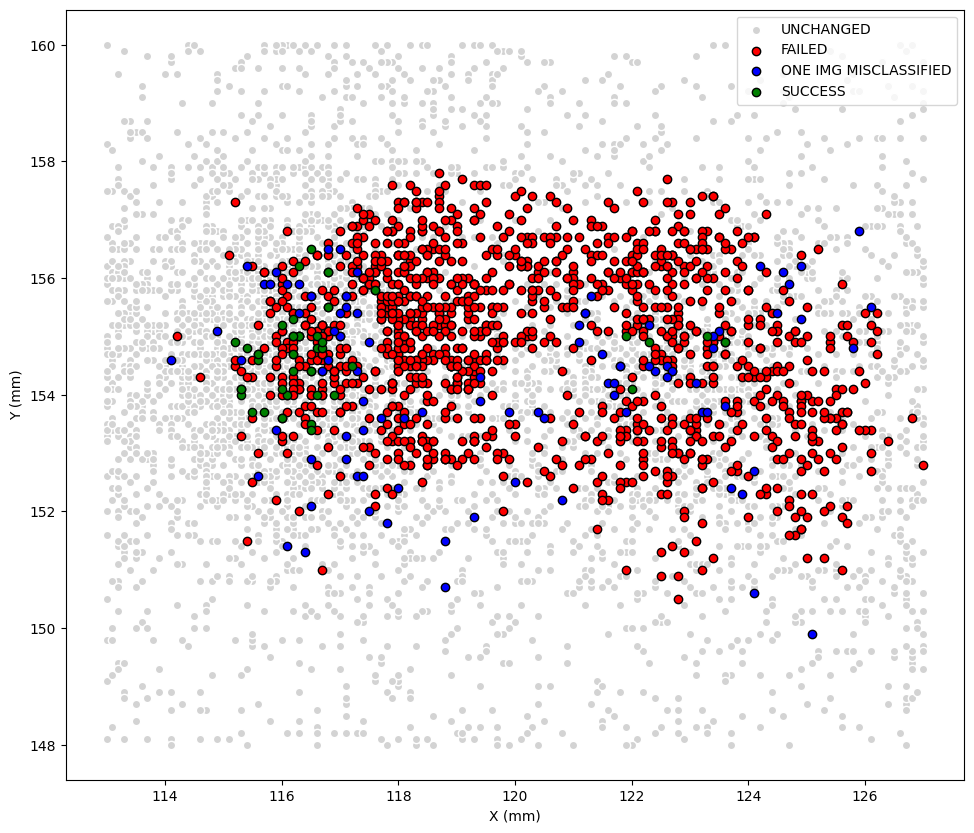

In [92]:
fig, ax = plt.subplots(figsize=(15, 10))

ax.set_aspect("equal")

ax.scatter(
    df_unchanged["params_x"],
    df_unchanged["params_y"],
    c="lightgray",
    linewidths=1,
    edgecolors="white",
    label="UNCHANGED",
)

ax.scatter(
    df_failed["params_x"],
    df_failed["params_y"],
    c="red",
    linewidths=1,
    edgecolors="black",
    label="FAILED",
)

ax.scatter(
    df_one["params_x"],
    df_one["params_y"],
    c="blue",
    linewidths=1,
    edgecolors="black",
    label="ONE IMG MISCLASSIFIED",
)

ax.scatter(
    df_success["params_x"],
    df_success["params_y"],
    c="green",
    linewidths=1,
    edgecolors="black",
    label="SUCCESS",
)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.legend()

plt.savefig("../../results/exploratory/1000_optuna/2d.svg")